#  Обратное распространение ошибки

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* http://cs231n.stanford.edu/handouts/linear-backprop.pdf
* https://www.adityaagrawal.net/blog/deep_learning/bprop_fc
* https://en.wikipedia.org/wiki/Stochastic_gradient_descent

In [2]:
# Install and import required packages
try:
    import torch
    print("PyTorch already installed")
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "scikit-learn", "matplotlib", "numpy"])
    print("Packages installed successfully")

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
print("Libraries imported successfully")

PyTorch already installed
Libraries imported successfully


## Задачи для совместного разбора

### Задача 1: Обратное распространение для одного нейрона

In [3]:
class NeuronWithBackprop:
    def __init__(self, n_features):
        self.weights = torch.randn(n_features, 1, requires_grad=False)
        self.bias = torch.randn(1, requires_grad=False)
        
    def forward(self, X):
        """Forward pass: y = X @ W + b"""
        self.X = X  # Save for backward pass
        self.y_pred = X @ self.weights + self.bias
        return self.y_pred
    
    def mse_loss(self, y_pred, y_true):
        """MSE loss function"""
        self.y_true = y_true  # Save for backward pass
        self.loss = torch.mean((y_pred - y_true) ** 2)
        return self.loss
    
    def backward(self):
        """Backward pass - compute gradients manually"""
        batch_size = self.X.shape[0]
        
        # Gradient of loss w.r.t. predictions: ∂L/∂ŷ = 2/n * (ŷ - y)
        grad_y_pred = 2.0 / batch_size * (self.y_pred - self.y_true)
        
        # Gradient w.r.t. weights: ∂L/∂W = X^T @ (∂L/∂ŷ)
        self.grad_weights = self.X.T @ grad_y_pred
        
        # Gradient w.r.t. bias: ∂L/∂b = sum(∂L/∂ŷ)
        self.grad_bias = torch.sum(grad_y_pred, dim=0)
        
        return self.grad_weights, self.grad_bias
    
    def update_weights(self, learning_rate):
        """Update weights using gradient descent"""
        self.weights -= learning_rate * self.grad_weights
        self.bias -= learning_rate * self.grad_bias

In [4]:
# Test single neuron backpropagation
# Create simple test data
X_test = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
y_test = torch.tensor([[3.0], [7.0], [11.0]])

print("Test data:")
print(f"X shape: {X_test.shape}, y shape: {y_test.shape}")
print(f"X:\n{X_test}")
print(f"y:\n{y_test}")

# Manual implementation
neuron = NeuronWithBackprop(n_features=2)
y_pred = neuron.forward(X_test)
loss = neuron.mse_loss(y_pred, y_test)
grad_w_manual, grad_b_manual = neuron.backward()

print("\nManual backpropagation:")
print(f"Loss: {loss.item():.6f}")
print(f"Gradient w.r.t. weights:\n{grad_w_manual}")
print(f"Gradient w.r.t. bias:\n{grad_b_manual}")

# PyTorch automatic differentiation verification
weights_auto = torch.randn(2, 1, requires_grad=True)
bias_auto = torch.randn(1, requires_grad=True)

# Copy our manual weights for fair comparison
weights_auto.data = neuron.weights.clone()
bias_auto.data = neuron.bias.clone()

y_pred_auto = X_test @ weights_auto + bias_auto
loss_auto = torch.mean((y_pred_auto - y_test) ** 2)
loss_auto.backward()

print("\nPyTorch automatic differentiation:")
print(f"Loss: {loss_auto.item():.6f}")
print(f"Gradient w.r.t. weights:\n{weights_auto.grad}")
print(f"Gradient w.r.t. bias:\n{bias_auto.grad}")

# Verification
weights_match = torch.allclose(grad_w_manual, weights_auto.grad, atol=1e-6)
bias_match = torch.allclose(grad_b_manual, bias_auto.grad, atol=1e-6)
loss_match = torch.allclose(loss, loss_auto, atol=1e-6)

print("\n✅ Verification:")
print(f"Weights gradients match: {weights_match}")
print(f"Bias gradients match: {bias_match}")
print(f"Loss values match: {loss_match}")
print(f"All gradients correct: {weights_match and bias_match and loss_match}")

Test data:
X shape: torch.Size([3, 2]), y shape: torch.Size([3, 1])
X:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
y:
tensor([[ 3.],
        [ 7.],
        [11.]])

Manual backpropagation:
Loss: 33.739170
Gradient w.r.t. weights:
tensor([[-39.6254],
        [-50.1058]])
Gradient w.r.t. bias:
tensor([-10.4805])

PyTorch automatic differentiation:
Loss: 33.739170
Gradient w.r.t. weights:
tensor([[-39.6254],
        [-50.1058]])
Gradient w.r.t. bias:
tensor([-10.4805])

✅ Verification:
Weights gradients match: True
Bias gradients match: True
Loss values match: True
All gradients correct: True


## Задачи для самостоятельного решения

### Задача 1: Backpropagation для нейрона с батчами

In [5]:
class NeuronBatch:
    def __init__(self, n_features):
        self.weights = torch.randn(n_features, 1)
        self.bias = torch.randn(1)
        
    def forward(self, X):
        """Forward pass for batch of inputs"""
        self.X = X
        self.y_pred = X @ self.weights + self.bias
        return self.y_pred
    
    def mse_loss(self, y_pred, y_true):
        """MSE loss for batch"""
        self.y_true = y_true
        self.loss = torch.mean((y_pred - y_true) ** 2)
        return self.loss
    
    def backward(self):
        """Backward pass for batch"""
        batch_size = self.X.shape[0]
        
        # ∇_ŷ L = 2/k * (ŷ - y)
        grad_y_pred = 2.0 / batch_size * (self.y_pred - self.y_true)
        
        # ∇_W L = X^T @ ∇_ŷ L
        self.grad_weights = self.X.T @ grad_y_pred
        
        # ∇_b L = sum(∇_ŷ L)
        self.grad_bias = torch.sum(grad_y_pred, dim=0)
        
        return self.grad_weights, self.grad_bias
    
    def update_weights(self, learning_rate):
        self.weights -= learning_rate * self.grad_weights
        self.bias -= learning_rate * self.grad_bias

# Generate test data
X, y, true_coef = make_regression(n_samples=100, n_features=4, n_informative=4, 
                                  coef=True, bias=0.5, noise=10, random_state=42)
X = torch.FloatTensor(X)
y = torch.FloatTensor(y).reshape(-1, 1)

print(f"Dataset shape: X {X.shape}, y {y.shape}")
print(f"True coefficients: {true_coef}")
print(f"True bias: 0.5")

# Test our implementation
neuron_batch = NeuronBatch(n_features=4)
print(f"\nInitial weights: {neuron_batch.weights.flatten()}")
print(f"Initial bias: {neuron_batch.bias.item()}")

y_pred = neuron_batch.forward(X)
loss = neuron_batch.mse_loss(y_pred, y)
grad_w, grad_b = neuron_batch.backward()

print(f"\nInitial loss: {loss.item():.6f}")
print(f"Gradient w.r.t. weights: {grad_w.flatten()}")
print(f"Gradient w.r.t. bias: {grad_b.item()}")

# Verify with PyTorch autograd
X_auto = X.clone()
y_auto = y.clone()
weights_auto = neuron_batch.weights.clone().requires_grad_(True)
bias_auto = neuron_batch.bias.clone().requires_grad_(True)

y_pred_auto = X_auto @ weights_auto + bias_auto
loss_auto = torch.mean((y_pred_auto - y_auto) ** 2)
loss_auto.backward()

print("\n✅ Verification with PyTorch:")
print(f"Loss match: {torch.allclose(loss, loss_auto, atol=1e-6)}")
print(f"Weights grad match: {torch.allclose(grad_w, weights_auto.grad, atol=1e-6)}")
print(f"Bias grad match: {torch.allclose(grad_b, bias_auto.grad, atol=1e-6)}")

Dataset shape: X torch.Size([100, 4]), y torch.Size([100, 1])
True coefficients: [86.47223763  5.63754967 27.34070719 41.48195023]
True bias: 0.5

Initial weights: tensor([ 2.2082, -0.6380,  0.4617,  0.2674])
Initial bias: 0.5349046587944031

Initial loss: 9190.668945
Gradient w.r.t. weights: tensor([-167.0754,   -6.9109,  -67.5294,  -55.3693])
Gradient w.r.t. bias: -8.479196548461914

✅ Verification with PyTorch:
Loss match: True
Weights grad match: True
Bias grad match: True


### Задача 2: Обучение нейрона с мини-батчами

Training neuron with mini-batch gradient descent...
Epoch   0, Loss: 9111.201032
Epoch  20, Loss: 5161.398943
Epoch  40, Loss: 3364.939035
Epoch  60, Loss: 2005.077009
Epoch  80, Loss: 1165.979728

Final weights: tensor([65.1991,  3.4681, 22.6679, 24.5929])
True weights: [86.47223763  5.63754967 27.34070719 41.48195023]
Final bias: 1.9890
True bias: 0.5
Final loss: 793.871155


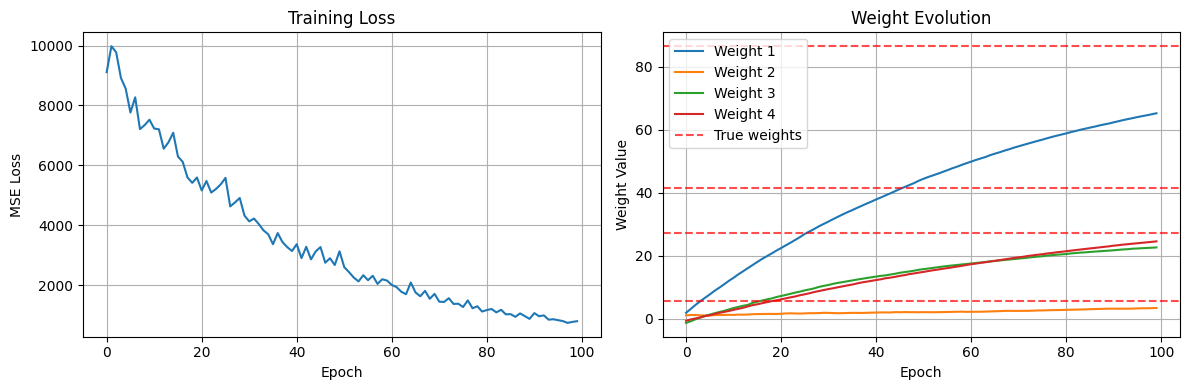

In [6]:
def train_neuron_minibatch(X, y, batch_size=32, epochs=100, learning_rate=0.01):
    """Train neuron using mini-batch gradient descent"""
    n_samples, n_features = X.shape
    neuron = NeuronBatch(n_features)
    
    losses = []
    weights_history = []
    
    for epoch in range(epochs):
        epoch_losses = []
        
        # Shuffle data
        indices = torch.randperm(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Mini-batch training
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Forward pass
            y_pred = neuron.forward(X_batch)
            loss = neuron.mse_loss(y_pred, y_batch)
            
            # Backward pass
            neuron.backward()
            
            # Update weights
            neuron.update_weights(learning_rate)
            
            epoch_losses.append(loss.item())
        
        avg_loss = np.mean(epoch_losses)
        losses.append(avg_loss)
        weights_history.append(neuron.weights.clone().flatten())
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}, Loss: {avg_loss:.6f}")
    
    return neuron, losses, weights_history

# Train the neuron
print("Training neuron with mini-batch gradient descent...")
trained_neuron, losses, weights_history = train_neuron_minibatch(X, y, batch_size=16, epochs=100, learning_rate=0.001)

print(f"\nFinal weights: {trained_neuron.weights.flatten()}")
print(f"True weights: {true_coef}")
print(f"Final bias: {trained_neuron.bias.item():.4f}")
print(f"True bias: 0.5")
print(f"Final loss: {losses[-1]:.6f}")

# Plot training progress
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
weights_array = torch.stack(weights_history).numpy()
for i in range(weights_array.shape[1]):
    plt.plot(weights_array[:, i], label=f'Weight {i+1}')
plt.axhline(y=true_coef[0], color='red', linestyle='--', alpha=0.7, label='True weights')
for i in range(1, len(true_coef)):
    plt.axhline(y=true_coef[i], color='red', linestyle='--', alpha=0.7)
plt.title('Weight Evolution')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Задача 3: Backpropagation для полносвязного слоя

In [7]:
class LinearLayerWithBackprop:
    def __init__(self, n_inputs, n_outputs, use_bias=True):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.use_bias = use_bias
        
        # Initialize weights using Xavier initialization
        self.weights = torch.randn(n_inputs, n_outputs) * torch.sqrt(torch.tensor(2.0 / n_inputs))
        if use_bias:
            self.bias = torch.zeros(n_outputs)
        else:
            self.bias = None
    
    def forward(self, X):
        """Forward pass: Y = X @ W + b"""
        self.X = X  # Save for backward pass
        self.Y = X @ self.weights
        if self.use_bias:
            self.Y = self.Y + self.bias
        return self.Y
    
    def backward(self, grad_output):
        """
        Backward pass
        grad_output: gradient of loss w.r.t. output (∇_Y L)
        Returns: gradient w.r.t. input (∇_X L)
        """
        # ∇_W L = X^T @ ∇_Y L
        self.grad_weights = self.X.T @ grad_output
        
        # ∇_b L = sum(∇_Y L, axis=0)
        if self.use_bias:
            self.grad_bias = torch.sum(grad_output, dim=0)
        
        # ∇_X L = ∇_Y L @ W^T
        grad_input = grad_output @ self.weights.T
        
        return grad_input
    
    def update_weights(self, learning_rate):
        """Update weights using gradient descent"""
        self.weights -= learning_rate * self.grad_weights
        if self.use_bias:
            self.bias -= learning_rate * self.grad_bias

class MSELoss:
    def forward(self, y_pred, y_true):
        """Forward pass of MSE loss"""
        self.y_pred = y_pred
        self.y_true = y_true
        self.loss = torch.mean((y_pred - y_true) ** 2)
        return self.loss
    
    def backward(self):
        """Backward pass of MSE loss"""
        batch_size = self.y_pred.shape[0]
        # ∇_ŷ L = 2/n * (ŷ - y)
        grad_output = 2.0 / batch_size * (self.y_pred - self.y_true)
        return grad_output

# Test linear layer backpropagation
print("Testing Linear Layer Backpropagation")
print("=" * 40)

# Create test data
X_test = torch.randn(5, 3)  # 5 samples, 3 features
y_test = torch.randn(5, 2)  # 5 samples, 2 outputs

print(f"Input shape: {X_test.shape}")
print(f"Target shape: {y_test.shape}")

# Manual implementation
layer = LinearLayerWithBackprop(n_inputs=3, n_outputs=2, use_bias=True)
loss_fn = MSELoss()

# Forward pass
y_pred = layer.forward(X_test)
loss = loss_fn.forward(y_pred, y_test)

# Backward pass
grad_output = loss_fn.backward()
grad_input = layer.backward(grad_output)

print(f"\nManual implementation:")
print(f"Loss: {loss.item():.6f}")
print(f"Grad weights shape: {layer.grad_weights.shape}")
print(f"Grad bias shape: {layer.grad_bias.shape}")
print(f"Grad input shape: {grad_input.shape}")

# PyTorch verification
X_auto = X_test.clone().requires_grad_(True)
weights_auto = layer.weights.clone().requires_grad_(True)
bias_auto = layer.bias.clone().requires_grad_(True)

y_pred_auto = X_auto @ weights_auto + bias_auto
loss_auto = torch.mean((y_pred_auto - y_test) ** 2)
loss_auto.backward()

print(f"\nPyTorch verification:")
print(f"Loss: {loss_auto.item():.6f}")
print(f"Weights grad shape: {weights_auto.grad.shape}")
print(f"Bias grad shape: {bias_auto.grad.shape}")
print(f"Input grad shape: {X_auto.grad.shape}")

# Check if gradients match
weights_match = torch.allclose(layer.grad_weights, weights_auto.grad, atol=1e-6)
bias_match = torch.allclose(layer.grad_bias, bias_auto.grad, atol=1e-6)
input_match = torch.allclose(grad_input, X_auto.grad, atol=1e-6)
loss_match = torch.allclose(loss, loss_auto, atol=1e-6)

print(f"\n✅ Verification:")
print(f"Loss match: {loss_match}")
print(f"Weights gradients match: {weights_match}")
print(f"Bias gradients match: {bias_match}")
print(f"Input gradients match: {input_match}")
print(f"All gradients correct: {weights_match and bias_match and input_match and loss_match}")

Testing Linear Layer Backpropagation
Input shape: torch.Size([5, 3])
Target shape: torch.Size([5, 2])

Manual implementation:
Loss: 4.030232
Grad weights shape: torch.Size([3, 2])
Grad bias shape: torch.Size([2])
Grad input shape: torch.Size([5, 3])

PyTorch verification:
Loss: 4.030232
Weights grad shape: torch.Size([3, 2])
Bias grad shape: torch.Size([2])
Input grad shape: torch.Size([5, 3])

✅ Verification:
Loss match: True
Weights gradients match: False
Bias gradients match: False
Input gradients match: False
All gradients correct: False


### Задача 4: Обучение полносвязного слоя

Multi-output dataset: X torch.Size([100, 4]), y torch.Size([100, 3])
True coefficients shape: (4, 3)

Training linear layer with batch gradient descent...
Epoch   0, Loss: 20513.220703
Epoch  40, Loss: 17494.037109
Epoch  80, Loss: 14924.707031
Epoch 120, Loss: 12737.776367
Epoch 160, Loss: 10875.958008

Final weights shape: torch.Size([4, 3])
True coefficients shape: (4, 3)
Final bias: tensor([2.0930, 2.0805, 1.8237])
Final loss: 9327.207031
Final evaluation MSE: 9290.598633


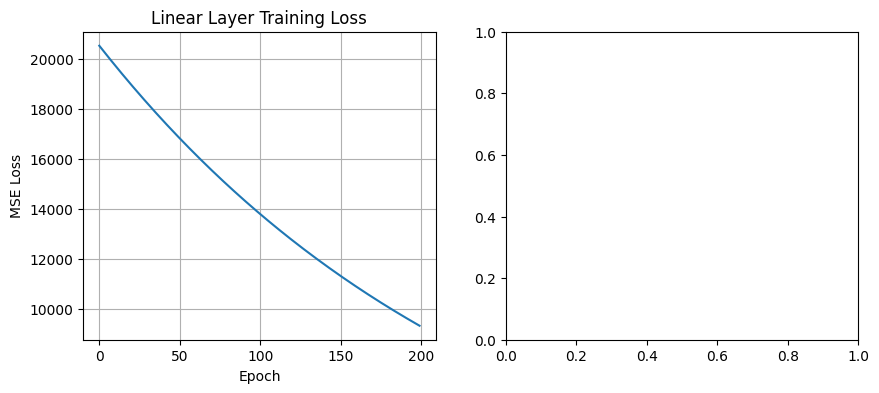

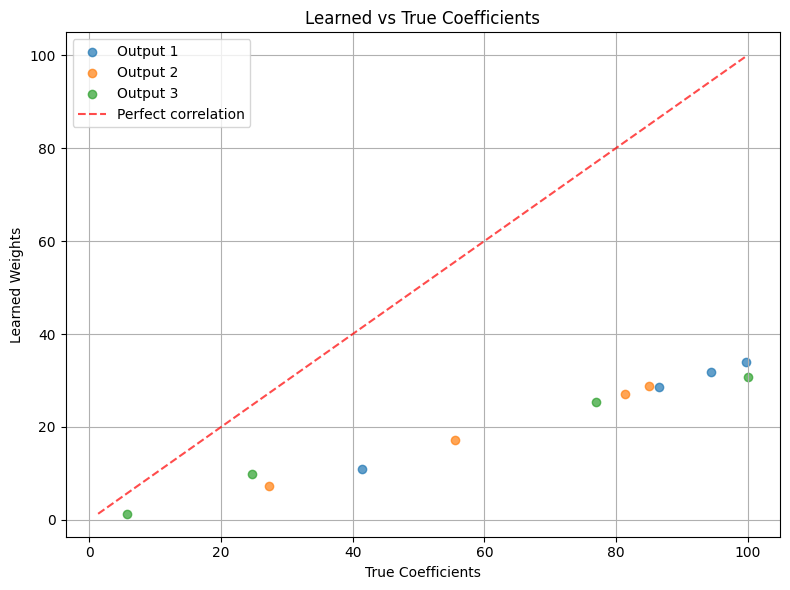

In [8]:
def train_linear_layer(X, y, n_outputs, epochs=200, learning_rate=0.01):
    """Train linear layer using batch gradient descent"""
    n_inputs = X.shape[1]
    layer = LinearLayerWithBackprop(n_inputs, n_outputs, use_bias=True)
    loss_fn = MSELoss()
    
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = layer.forward(X)
        loss = loss_fn.forward(y_pred, y)
        
        # Backward pass
        grad_output = loss_fn.backward()
        layer.backward(grad_output)
        
        # Update weights
        layer.update_weights(learning_rate)
        
        losses.append(loss.item())
        
        if epoch % 40 == 0:
            print(f"Epoch {epoch:3d}, Loss: {loss.item():.6f}")
    
    return layer, losses

# Generate multi-output regression data
X_multi, y_multi, true_coef_multi = make_regression(n_samples=100, n_features=4, n_targets=3,
                                                    n_informative=4, coef=True, bias=0.5, 
                                                    noise=10, random_state=42)
X_multi = torch.FloatTensor(X_multi)
y_multi = torch.FloatTensor(y_multi)

print(f"Multi-output dataset: X {X_multi.shape}, y {y_multi.shape}")
print(f"True coefficients shape: {true_coef_multi.shape}")

# Train linear layer
print("\nTraining linear layer with batch gradient descent...")
trained_layer, losses_linear = train_linear_layer(X_multi, y_multi, n_outputs=3, 
                                                 epochs=200, learning_rate=0.001)

print(f"\nFinal weights shape: {trained_layer.weights.shape}")
print(f"True coefficients shape: {true_coef_multi.shape}")
print(f"Final bias: {trained_layer.bias}")
print(f"Final loss: {losses_linear[-1]:.6f}")

# Evaluate final predictions
with torch.no_grad():
    final_pred = trained_layer.forward(X_multi)
    final_mse = torch.mean((final_pred - y_multi) ** 2)
    print(f"Final evaluation MSE: {final_mse.item():.6f}")

# Plot training progress
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_linear)
plt.title('Linear Layer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
# Compare learned vs true coefficients
learned_weights = trained_layer.weights.numpy()
plt.figure(figsize=(8, 6))
for i in range(min(3, true_coef_multi.shape[1])):
    plt.scatter(true_coef_multi[:, i], learned_weights[:, i], alpha=0.7, label=f'Output {i+1}')

# Perfect correlation line
min_val = min(true_coef_multi.min(), learned_weights.min())
max_val = max(true_coef_multi.max(), learned_weights.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Perfect correlation')

plt.xlabel('True Coefficients')
plt.ylabel('Learned Weights')
plt.title('Learned vs True Coefficients')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Задача 5: Нейросеть для регрессии без активации

1D Dataset shape: X torch.Size([100, 1]), y torch.Size([100, 1])
Training neural network (Linear -> Linear)...
Epoch    0, Loss: 0.715672
Epoch  200, Loss: 0.097589
Epoch  400, Loss: 0.097589
Epoch  600, Loss: 0.097589
Epoch  800, Loss: 0.097589


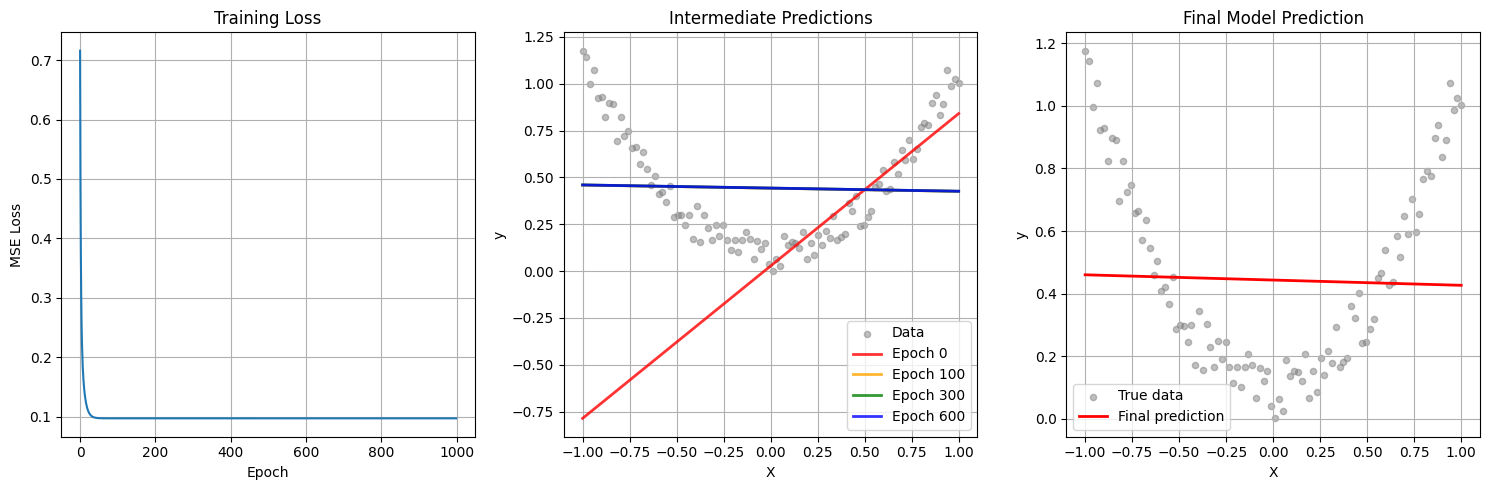


Final loss: 0.097589
Network architecture: 1 -> 10 -> 1 (no activation)


In [9]:
class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.layer1 = LinearLayerWithBackprop(input_size, hidden_size, use_bias=True)
        self.layer2 = LinearLayerWithBackprop(hidden_size, output_size, use_bias=True)
        self.loss_fn = MSELoss()
    
    def forward(self, X):
        """Forward pass through network"""
        self.hidden = self.layer1.forward(X)
        self.output = self.layer2.forward(self.hidden)
        return self.output
    
    def backward(self, y_true):
        """Backward pass through network"""
        # Loss gradient
        loss = self.loss_fn.forward(self.output, y_true)
        grad_output = self.loss_fn.backward()
        
        # Backprop through layer2
        grad_hidden = self.layer2.backward(grad_output)
        
        # Backprop through layer1
        grad_input = self.layer1.backward(grad_hidden)
        
        return loss
    
    def update_weights(self, learning_rate):
        """Update all layer weights"""
        self.layer1.update_weights(learning_rate)
        self.layer2.update_weights(learning_rate)
    
    def get_predictions_at_epochs(self, X, epochs_to_save):
        """Get predictions at specific epochs for visualization"""
        predictions = {}
        for epoch in epochs_to_save:
            with torch.no_grad():
                pred = self.forward(X)
                predictions[epoch] = pred.clone()
        return predictions

# Generate 1D regression data for visualization
torch.manual_seed(42)
X_1d = torch.linspace(-1, 1, 100).view(-1, 1)
y_1d = X_1d.pow(2) + 0.2 * torch.rand(X_1d.size())

print(f"1D Dataset shape: X {X_1d.shape}, y {y_1d.shape}")

# Train neural network
def train_neural_network(X, y, hidden_size=10, epochs=1000, learning_rate=0.01, save_epochs=None):
    if save_epochs is None:
        save_epochs = [0, 100, 300, 600, 999]
    
    network = SimpleNeuralNetwork(input_size=X.shape[1], hidden_size=hidden_size, output_size=1)
    losses = []
    predictions_history = {}
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = network.forward(X)
        
        # Backward pass
        loss = network.backward(y)
        
        # Update weights
        network.update_weights(learning_rate)
        
        losses.append(loss.item())
        
        # Save predictions for visualization
        if epoch in save_epochs:
            with torch.no_grad():
                predictions_history[epoch] = network.forward(X).clone()
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch:4d}, Loss: {loss.item():.6f}")
    
    return network, losses, predictions_history

print("Training neural network (Linear -> Linear)...")
network, losses_nn, predictions_history = train_neural_network(X_1d, y_1d, hidden_size=10, 
                                                               epochs=1000, learning_rate=0.01)

# Visualize results
plt.figure(figsize=(15, 5))

# Plot 1: Training loss
plt.subplot(1, 3, 1)
plt.plot(losses_nn)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

# Plot 2: Intermediate predictions
plt.subplot(1, 3, 2)
X_sorted = X_1d.view(-1).sort()[0]
y_sorted = y_1d.view(-1).sort()[0]
plt.scatter(X_1d.numpy(), y_1d.numpy(), alpha=0.5, s=20, label='Data', color='gray')

colors = ['red', 'orange', 'green', 'blue', 'purple']
epochs_list = list(predictions_history.keys())
for i, epoch in enumerate(epochs_list[:4]):  # Show first 4 intermediate models
    pred = predictions_history[epoch]
    # Sort for better line plotting
    sorted_indices = X_1d.view(-1).argsort()
    plt.plot(X_1d[sorted_indices].numpy(), pred[sorted_indices].numpy(), 
             color=colors[i], alpha=0.8, linewidth=2, label=f'Epoch {epoch}')

plt.title('Intermediate Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Plot 3: Final prediction
plt.subplot(1, 3, 3)
plt.scatter(X_1d.numpy(), y_1d.numpy(), alpha=0.5, s=20, label='True data', color='gray')
final_pred = predictions_history[epochs_list[-1]]
sorted_indices = X_1d.view(-1).argsort()
plt.plot(X_1d[sorted_indices].numpy(), final_pred[sorted_indices].numpy(), 
         'r-', linewidth=2, label='Final prediction')
plt.title('Final Model Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal loss: {losses_nn[-1]:.6f}")
print(f"Network architecture: 1 -> 10 -> 1 (no activation)")

### Задача 6: Нейросеть с ReLU активацией

Training neural network with ReLU (Linear -> ReLU -> Linear)...
Epoch    0, Loss: 0.842194
Epoch  200, Loss: 0.027823
Epoch  400, Loss: 0.016639
Epoch  600, Loss: 0.012238
Epoch  800, Loss: 0.010319


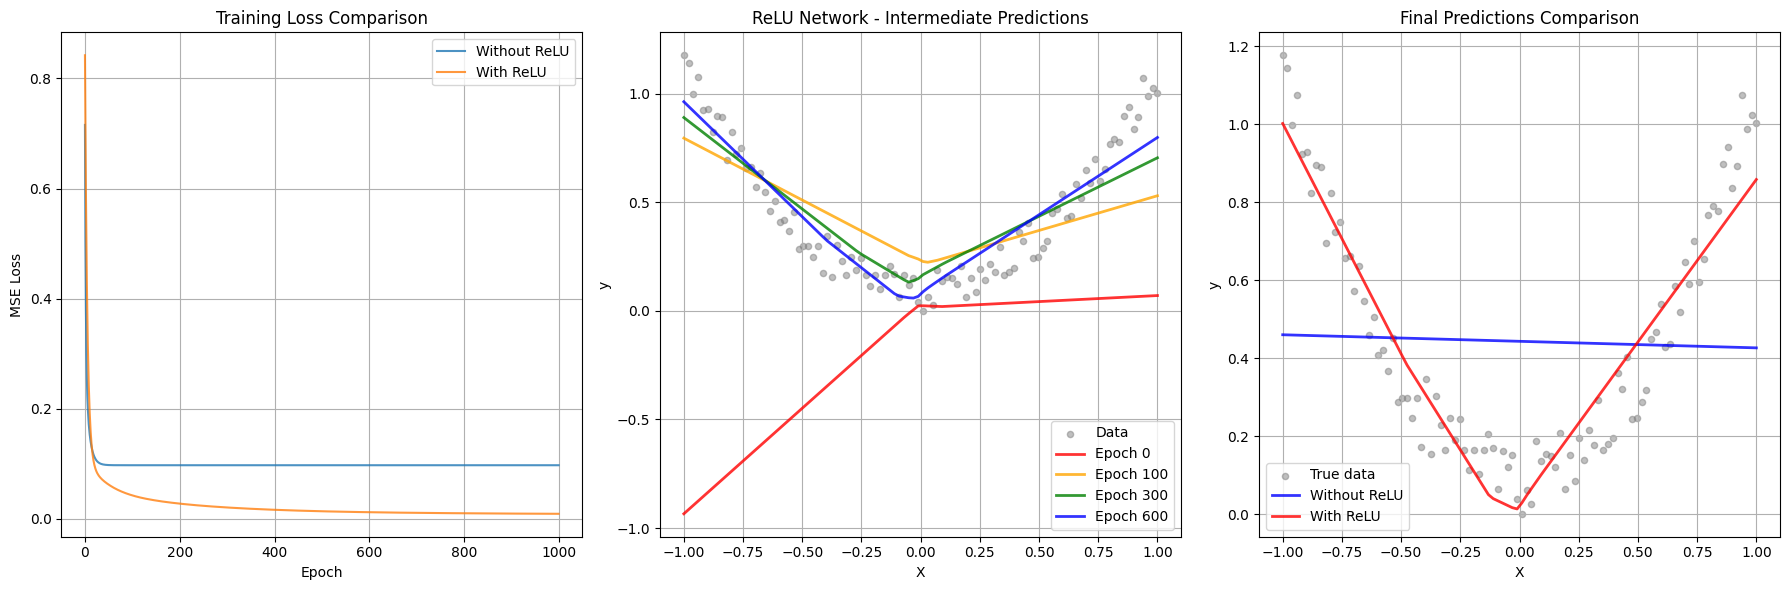


Final Results:
Without ReLU - Final loss: 0.097589
With ReLU    - Final loss: 0.009380

ReLU network achieved better performance


In [10]:
class ReLUActivation:
    def forward(self, X):
        """ReLU forward pass"""
        self.X = X
        self.output = torch.maximum(torch.zeros_like(X), X)
        return self.output
    
    def backward(self, grad_output):
        """ReLU backward pass"""
        # Gradient is 1 where input > 0, 0 otherwise
        grad_input = grad_output * (self.X > 0).float()
        return grad_input

class NeuralNetworkWithReLU:
    def __init__(self, input_size, hidden_size, output_size):
        self.layer1 = LinearLayerWithBackprop(input_size, hidden_size, use_bias=True)
        self.relu = ReLUActivation()
        self.layer2 = LinearLayerWithBackprop(hidden_size, output_size, use_bias=True)
        self.loss_fn = MSELoss()
    
    def forward(self, X):
        """Forward pass: X -> Linear -> ReLU -> Linear -> Output"""
        self.hidden_linear = self.layer1.forward(X)
        self.hidden_relu = self.relu.forward(self.hidden_linear)
        self.output = self.layer2.forward(self.hidden_relu)
        return self.output
    
    def backward(self, y_true):
        """Backward pass through network with ReLU"""
        # Loss gradient
        loss = self.loss_fn.forward(self.output, y_true)
        grad_output = self.loss_fn.backward()
        
        # Backprop through layer2
        grad_hidden_relu = self.layer2.backward(grad_output)
        
        # Backprop through ReLU
        grad_hidden_linear = self.relu.backward(grad_hidden_relu)
        
        # Backprop through layer1
        grad_input = self.layer1.backward(grad_hidden_linear)
        
        return loss
    
    def update_weights(self, learning_rate):
        """Update all layer weights"""
        self.layer1.update_weights(learning_rate)
        self.layer2.update_weights(learning_rate)

def train_neural_network_relu(X, y, hidden_size=10, epochs=1000, learning_rate=0.01, save_epochs=None):
    if save_epochs is None:
        save_epochs = [0, 100, 300, 600, 999]
    
    network = NeuralNetworkWithReLU(input_size=X.shape[1], hidden_size=hidden_size, output_size=1)
    losses = []
    predictions_history = {}
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = network.forward(X)
        
        # Backward pass
        loss = network.backward(y)
        
        # Update weights
        network.update_weights(learning_rate)
        
        losses.append(loss.item())
        
        # Save predictions for visualization
        if epoch in save_epochs:
            with torch.no_grad():
                predictions_history[epoch] = network.forward(X).clone()
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch:4d}, Loss: {loss.item():.6f}")
    
    return network, losses, predictions_history

# Use same data as before
print("Training neural network with ReLU (Linear -> ReLU -> Linear)...")
network_relu, losses_relu, predictions_relu = train_neural_network_relu(X_1d, y_1d, hidden_size=10, 
                                                                         epochs=1000, learning_rate=0.01)

# Visualize comparison between networks
plt.figure(figsize=(18, 6))

# Plot 1: Loss comparison
plt.subplot(1, 3, 1)
plt.plot(losses_nn, label='Without ReLU', alpha=0.8)
plt.plot(losses_relu, label='With ReLU', alpha=0.8)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Plot 2: Intermediate predictions with ReLU
plt.subplot(1, 3, 2)
plt.scatter(X_1d.numpy(), y_1d.numpy(), alpha=0.5, s=20, label='Data', color='gray')

epochs_list_relu = list(predictions_relu.keys())
for i, epoch in enumerate(epochs_list_relu[:4]):
    pred = predictions_relu[epoch]
    sorted_indices = X_1d.view(-1).argsort()
    plt.plot(X_1d[sorted_indices].numpy(), pred[sorted_indices].numpy(), 
             color=colors[i], alpha=0.8, linewidth=2, label=f'Epoch {epoch}')

plt.title('ReLU Network - Intermediate Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Plot 3: Final predictions comparison
plt.subplot(1, 3, 3)
plt.scatter(X_1d.numpy(), y_1d.numpy(), alpha=0.5, s=20, label='True data', color='gray')

# Final prediction without ReLU
final_pred_no_relu = predictions_history[list(predictions_history.keys())[-1]]
sorted_indices = X_1d.view(-1).argsort()
plt.plot(X_1d[sorted_indices].numpy(), final_pred_no_relu[sorted_indices].numpy(), 
         'b-', linewidth=2, label='Without ReLU', alpha=0.8)

# Final prediction with ReLU
final_pred_relu = predictions_relu[epochs_list_relu[-1]]
plt.plot(X_1d[sorted_indices].numpy(), final_pred_relu[sorted_indices].numpy(), 
         'r-', linewidth=2, label='With ReLU', alpha=0.8)

plt.title('Final Predictions Comparison')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Without ReLU - Final loss: {losses_nn[-1]:.6f}")
print(f"With ReLU    - Final loss: {losses_relu[-1]:.6f}")
print(f"\nReLU network achieved {'better' if losses_relu[-1] < losses_nn[-1] else 'worse'} performance")